<a href="https://colab.research.google.com/github/mukailaalhshituabr-cyber/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 3: Neural Networks: Feedforward Networks and the Training Process

Student Name: Abdoul-Raouf Mukaila Alh Shittu
Student ID: 30332027

In [12]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


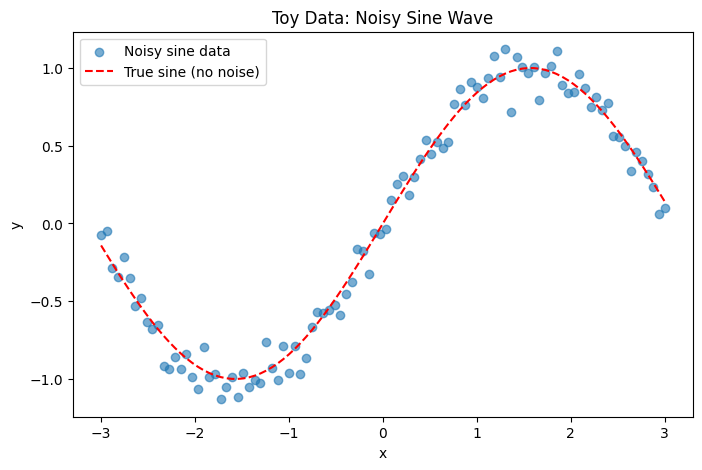

Initial w: 0.0497, b: -0.0138
Final w: 0.3380, b: -0.0126
No losses recorded


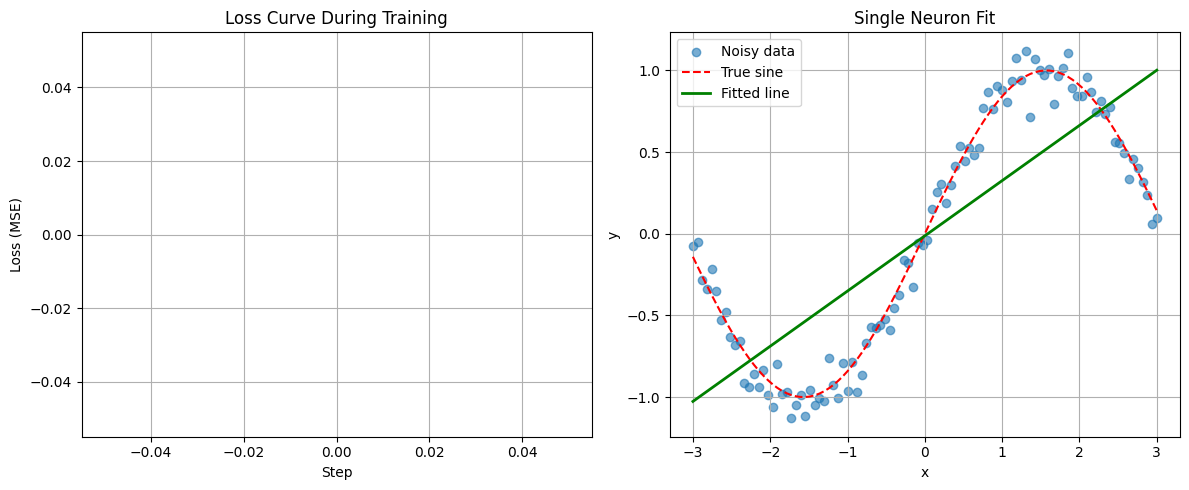

In [18]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

# Generate data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

# Plotting it
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label='Noisy sine data')
plt.plot(x, np.sin(x), 'r--', label='True sine (no noise)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy Data: Noisy Sine Wave')
plt.legend()
plt.show()

# TODO: Initialise w and b to small random values.
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
print(f"Initial w: {w:.4f}, b: {b:.4f}")

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
# Set learning rate
lr = 0.01
losses = []

for step in range(200):
   y_hat = w * x + b
   loss  = np.mean((y_hat - y) ** 2)               # MSE
   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
   db    = np.mean(2 * (y_hat - y))                # dLoss/db
   w    -= lr * dw
   b    -= lr * db
#   Record the loss at every step.

print(f"Final w: {w:.4f}, b: {b:.4f}")
if losses:
    print(f"Final loss: {losses[-1]:.6f}")
else:
    print("No losses recorded")

# TODO: Plot (a) the loss curve over the 200 steps, and
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss (MSE)')
plt.title('Loss Curve During Training')
plt.grid(True)
#             (b) the data with the fitted line on top.

plt.subplot(1, 2, 2)
plt.scatter(x, y, alpha=0.6, label='Noisy data')
plt.plot(x, np.sin(x), 'r--', label='True sine')
plt.plot(x, w * x + b, 'g-', label='Fitted line', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Single Neuron Fit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:

# Part 1.2 — Hidden layers and activations: why depth helps
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

In [ ]:
# Part 1.3 — The learning rate: too cold, too hot, just right
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.


In [ ]:
# Section 2
#Part 2.1 — Preprocess and split (recycled from Lab 2)


# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

In [ ]:
# Part 2.2 — Design the network


# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

In [ ]:
# Part 2.3 — The training loop


# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.


In [ ]:
# Part 2.4 — Experiments: how training choices change the outcome


# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.